In [52]:
# python
import sys
import importlib
# columnar analysis
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea import processor
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import sidm_processor, utilities, scaleout, selection, llpnanoaodschema
#from sidm.tools import llpnanoaodschema_0726 as llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(sidm_processor)
importlib.reload(utilities)
importlib.reload(scaleout)
importlib.reload(selection)
importlib.reload(llpnanoaodschema)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
from hist import Hist

In [53]:
client = scaleout.make_dask_client("tls://localhost:8786")
client

Connection method: Direct,
Dashboard: /user/knh3dg@virginia.edu/proxy/8787/status,
Comm: tls://192.168.197.253:8786,Workers: 0
Dashboard: /user/knh3dg@virginia.edu/proxy/8787/status,Total threads: 0
Started: 3 hours ago,Total memory: 0 B


In [54]:
 samples = [
   "TTJets", 

]
fileset = utilities.make_fileset(samples, 
                                 "llpNanoAOD_v2", 
                                 location_cfg="backgrounds.yaml",
                                 # max_files =100
                                  max_files = -1
                                )


runner = processor.Runner(
    #executor=processor.IterativeExecutor(),
    executor=processor.DaskExecutor(client=client),
    #schema=NanoAODSchema,
    #schema=llpnanoaodschema.NanoAODSchema,
    schema=llpnanoaodschema.LLPNanoAODSchema,
    #maxchunks=1,
    skipbadfiles=True,
)

channels = [
    '2mu_2LJ_CC',
    '2mu_2LJ_CC_charge',
    '2LJ_CC',
    '2LJ_CC_charge',
]

p = sidm_processor.SidmProcessor(
    channels,
    ["base"],
    verbose=True,
)


out = {}
for i, sample in enumerate(samples):
    print(f"Processing {sample}")
    fileset_one_sample = {samples[i]:fileset.get(samples[i])}
    output = runner.run(fileset_one_sample, treename='Events', processor_instance=p)
    #Add this sample's output to the out variable
    out[sample] = output["out"][sample]



Processing TTJets

Preprocessing 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248/248 [ 0:04:24 < 0:00:00 | 1.4 file/s ]

Processing 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249/249 [ 4:45:13 < 0:00:00 | 1.5 chunk/s ]

TTJets is simulation. Scaling histograms or cutflows according to lumi*xs.

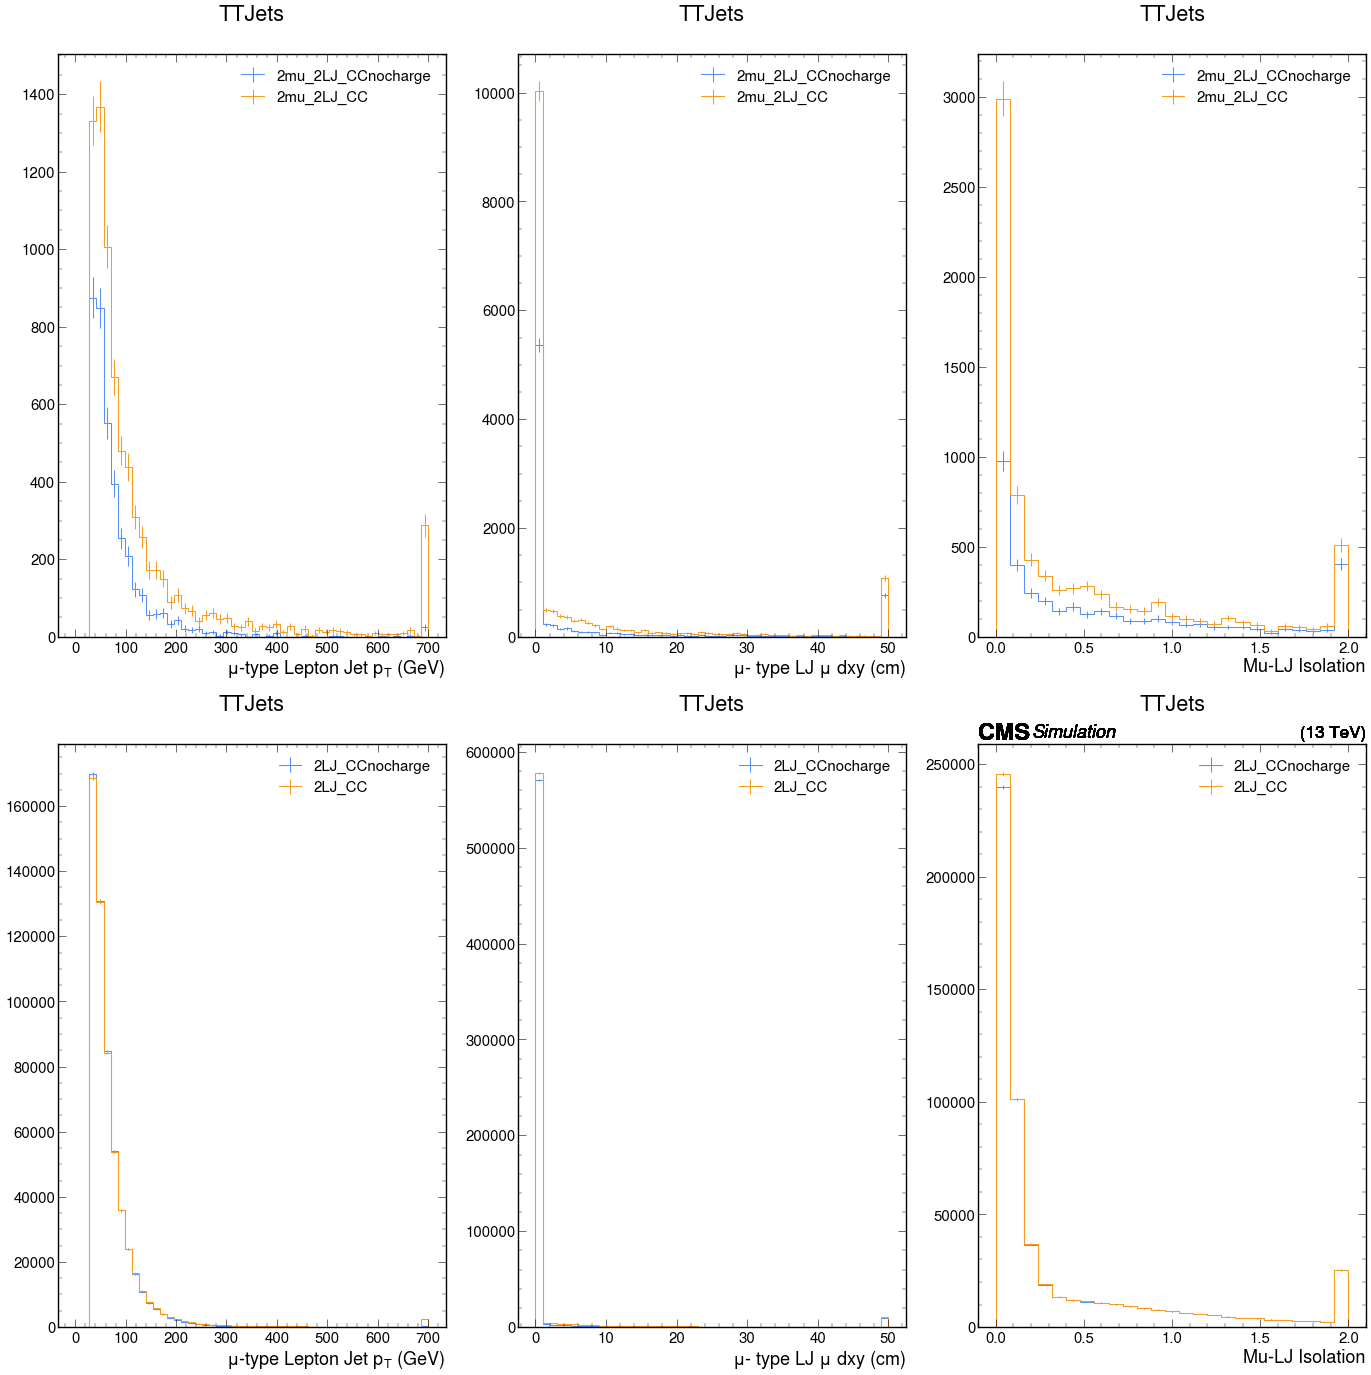

In [63]:
channel = [['2mu_2LJ_CCnocharge','2mu_2LJ_CC'],['2LJ_CCnocharge','2LJ_CC']]
fig, axes = plt.subplots(len(channel), 3, figsize=(28, 14*len(channel)))

for i in range(len(channel)):
    channel1 = channel[i][0]
    channel2 = channel[i][1]

    ax1, ax2, ax3 = axes[i]

    utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channel1, ::2j], label=channel1, ax=ax1)
    utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channel2, ::2j], label=channel2, ax=ax1)
    ax1.legend()
    ax1.set_title(samples[0],y=1.05)

    utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channel1, ::2j], label=channel1, ax=ax2)
    utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channel2, ::2j], label=channel2, ax=ax2)
    ax2.legend()
    ax2.set_title(samples[0],y=1.05)

    utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channel1, ::2j], label=channel1, ax=ax3)
    utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channel2, ::2j], label=channel2, ax=ax3)
    ax3.legend()
    ax3.set_title(samples[0],y=1.05)

plt.tight_layout()


The above graphs compare the amount of TTjet background that makes it through cross cleaning with and without a charge requirement. The graphs in the middle require two lepton jets with greater than or equal to two muons in the lepton jet, which mimics our selections for the final analysis. Notice that the addition of a charge requirment increases background by around 2x. This can be confirmed in the cell below. 

In [65]:
#ratio of lepton jets in each case
compare = ['mu_lj_pt']

for i in compare:
    print("Percent Change of Lepton Jets in Signal")
    for j in range(len(channels)//2):
        print(f'{channels[2*j+1]} / {channels[2*j]}: {out[samples[0]]["hists"][i][2*j+1, ::].values(flow=True).sum() / out[samples[0]]["hists"][i][2*j, ::].values(flow=True).sum()}')

Percent Change of Lepton Jets in Signal

2mu_2LJ_CC / 2mu_2LJ_CCnocharge: 2.018593371059014

2LJ_CC / 2LJ_CCnocharge: 1.0121924992141877

In [18]:
samples = [
    '2Mu2E_500GeV_1p2GeV_0p19mm',
    '2Mu2E_500GeV_1p2GeV_9p6mm',
    '2Mu2E_500GeV_1p2GeV_19p0mm',
]

fileset = utilities.make_fileset(samples, "llpNanoAOD_v2", max_files=100, location_cfg="signal_2mu2e_v10.yaml")

runner = processor.Runner(
    #executor=processor.IterativeExecutor(),
    executor=processor.DaskExecutor(client=client),
    #schema=NanoAODSchema,
    #schema=llpnanoaodschema.NanoAODSchema,
    schema=llpnanoaodschema.LLPNanoAODSchema,
    #maxchunks=1,
    skipbadfiles=True,
)

channels = [
    '2mu_2LJ_CC',
    '2mu_2LJ_CC_charge',
    '2LJ_CC',
    '2LJ_CC_charge',
]

p = sidm_processor.SidmProcessor(
    channels,
    ["base_plus_gen"],
    verbose=True,
)


out = {}
for i, sample in enumerate(samples):
    print(f"Processing {sample}")
    fileset_one_sample = {samples[i]:fileset.get(samples[i])}
    output = runner.run(fileset_one_sample, treename='Events', processor_instance=p)
    #Add this sample's output to the out variable
    out[sample] = output["out"][sample]

Processing 2Mu2E_500GeV_1p2GeV_0p19mm

Processing 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50/50 [ 0:16:08 < 0:00:00 | 4.9 chunk/s ]

2Mu2E_500GeV_1p2GeV_0p19mm is simulation. Scaling histograms or cutflows according to lumi*xs.

Signal not in xs cfg, assuming 1fb

Processing 2Mu2E_500GeV_1p2GeV_9p6mm

...

Signal not in xs cfg, assuming 1fb

Processing 2Mu2E_500GeV_1p2GeV_19p0mm

Processing 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52/52 [ 0:39:00 < 0:00:00 | 1.2 chunk/s ]

2Mu2E_500GeV_1p2GeV_19p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.

Signal not in xs cfg, assuming 1fb

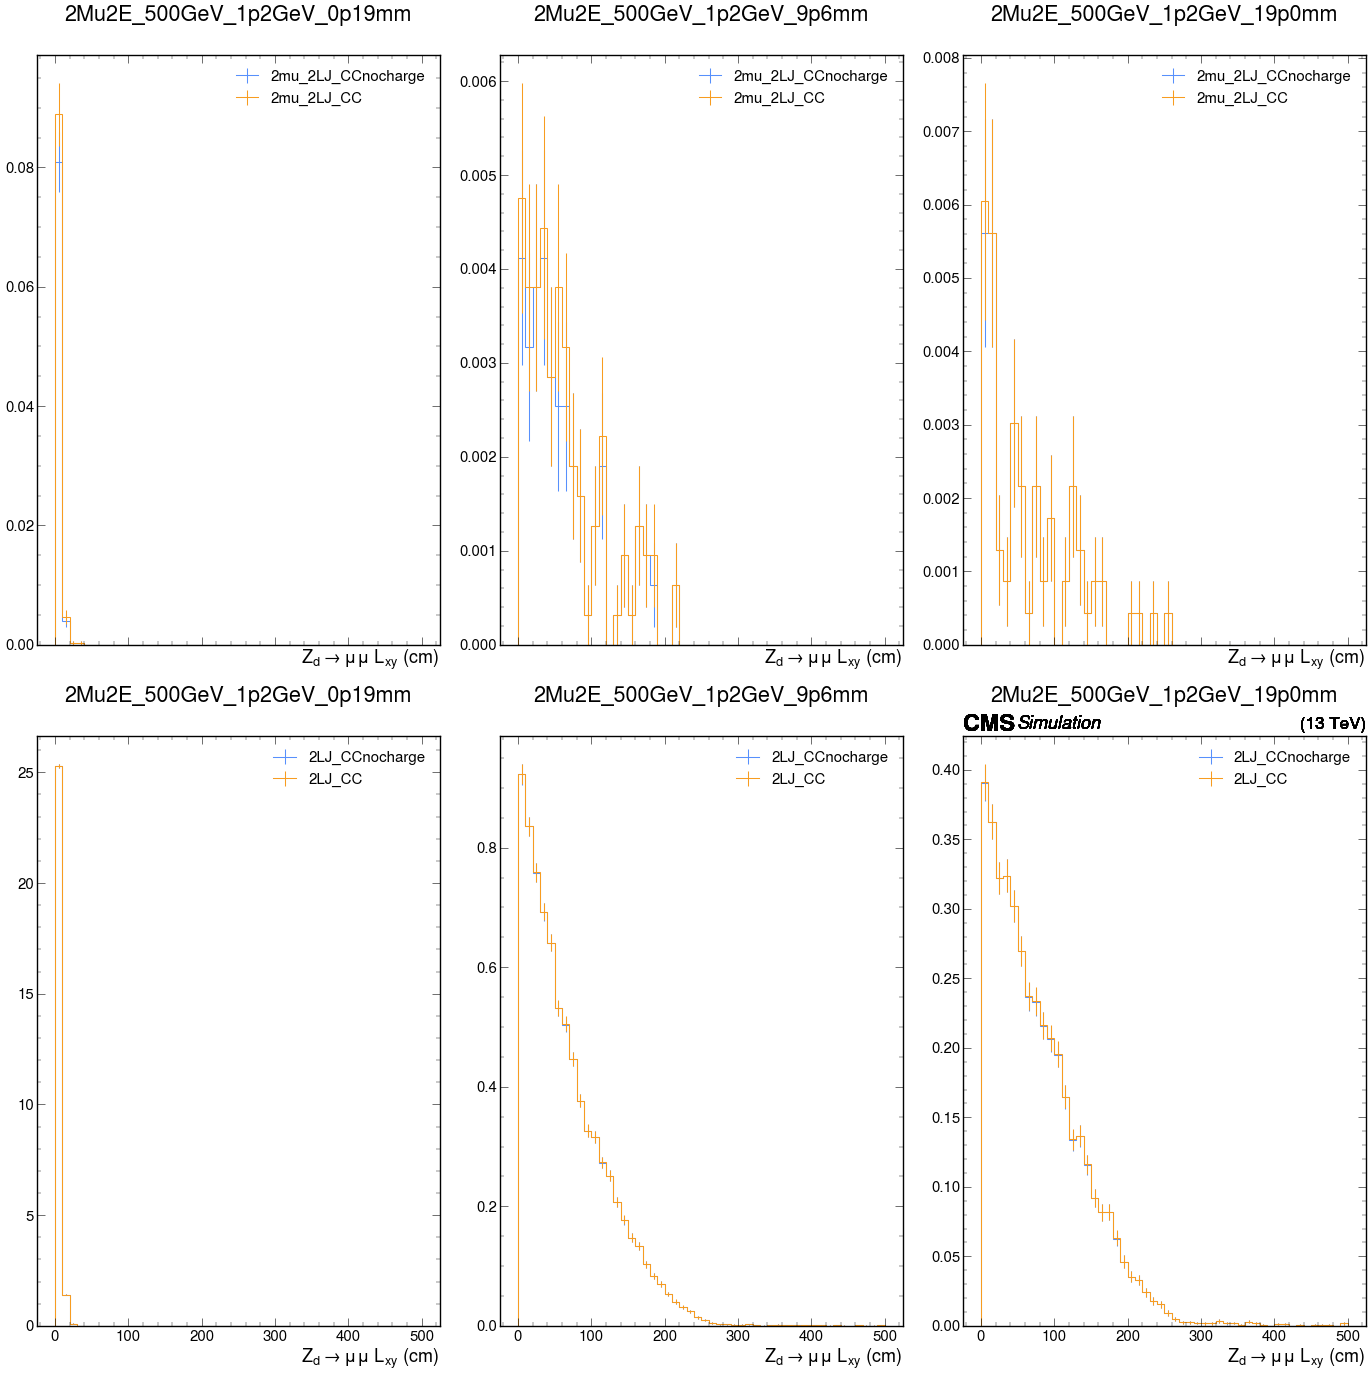

In [45]:
fig, axes = plt.subplots(len(channel), 3, figsize=(28, 14*len(channel)), sharex=True)
channel = [['2mu_2LJ_CCnocharge','2mu_2LJ_CC'],['2LJ_CCnocharge','2LJ_CC']]

for i in range(len(channel)):
    channel1 = channel[i][0]
    channel2 = channel[i][1]

    ax1, ax2, ax3 = axes[i]

    utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channel1, ::2j], label=channel1, ax=ax1)
    utilities.plot(out[samples[0]]["hists"]["genAs_toMu_lxy"][channel2, ::2j], label=channel2, ax=ax1)
    ax1.legend()
    ax1.set_title(samples[0],y=1.05)

    utilities.plot(out[samples[1]]["hists"]["genAs_toMu_lxy"][channel1, ::2j], label=channel1, ax=ax2)
    utilities.plot(out[samples[1]]["hists"]["genAs_toMu_lxy"][channel2, ::2j], label=channel2, ax=ax2)
    ax2.legend()
    ax2.set_title(samples[1],y=1.05)

    utilities.plot(out[samples[2]]["hists"]["genAs_toMu_lxy"][channel1, ::2j], label=channel1, ax=ax3)
    utilities.plot(out[samples[2]]["hists"]["genAs_toMu_lxy"][channel2, ::2j], label=channel2, ax=ax3)
    ax3.legend()
    ax3.set_title(samples[2],y=1.05)

plt.tight_layout()

In [51]:
#ratio of dark photons in each case
compare = ['genAs_toMu_lxy']

for i in compare:
    print("Percent Change of Dark Photons in Signal")
    for j in range(len(channels)//2):
        print(f'{channels[2*j+1]} / {channels[2*j]}: {out[samples[0]]["hists"][i][2*j+1, ::].values(flow=True).sum() / out[samples[0]]["hists"][i][2*j, ::].values(flow=True).sum()}')

Percent Change of Dark Photons in Signal

2mu_2LJ_CC / 2mu_2LJ_CCnocharge: 1.1018181818181818

2LJ_CC / 2LJ_CCnocharge: 1.0000464042506294

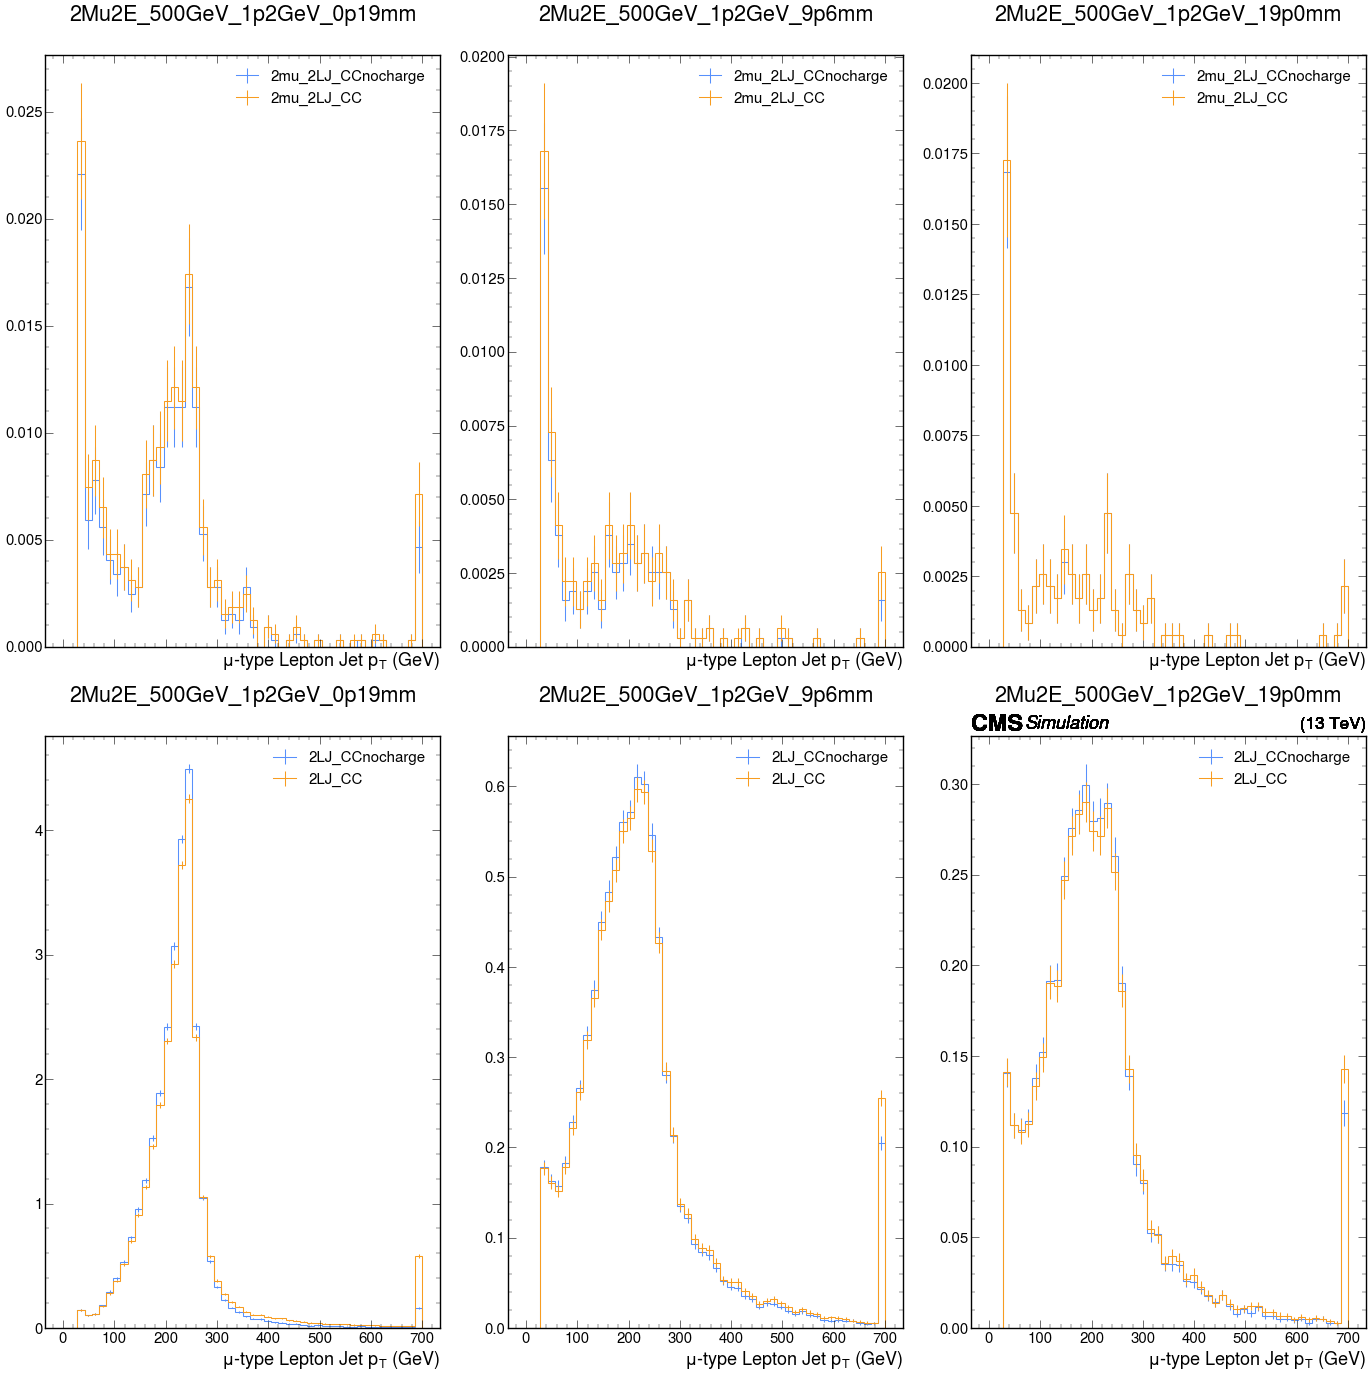

In [47]:
fig, axes = plt.subplots(len(channel), 3, figsize=(28, 14*len(channel)), sharex=True)
channel = [['2mu_2LJ_CCnocharge','2mu_2LJ_CC'],['2LJ_CCnocharge','2LJ_CC']]

for i in range(len(channel)):
    channel1 = channel[i][0]
    channel2 = channel[i][1]

    ax1, ax2, ax3 = axes[i]

    utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channel1, ::2j], label=channel1, ax=ax1)
    utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channel2, ::2j], label=channel2, ax=ax1)
    ax1.legend()
    ax1.set_title(samples[0],y=1.05)

    utilities.plot(out[samples[1]]["hists"]["mu_lj_pt"][channel1, ::2j], label=channel1, ax=ax2)
    utilities.plot(out[samples[1]]["hists"]["mu_lj_pt"][channel2, ::2j], label=channel2, ax=ax2)
    ax2.legend()
    ax2.set_title(samples[1],y=1.05)

    utilities.plot(out[samples[2]]["hists"]["mu_lj_pt"][channel1, ::2j], label=channel1, ax=ax3)
    utilities.plot(out[samples[2]]["hists"]["mu_lj_pt"][channel2, ::2j], label=channel2, ax=ax3)
    ax3.legend()
    ax3.set_title(samples[2],y=1.05)

plt.tight_layout()

In [50]:
#ratio of lepton jets in each case
compare = ['mu_lj_pt']

for i in compare:
    print("Percent Change of Lepton Jets in Signal")
    for j in range(len(channels)//2):
        print(f'{channels[2*j+1]} / {channels[2*j]}: {out[samples[0]]["hists"][i][2*j+1, ::].values(flow=True).sum() / out[samples[0]]["hists"][i][2*j, ::].values(flow=True).sum()}')

Percent Change of Lepton Jets in Signal

2mu_2LJ_CC / 2mu_2LJ_CCnocharge: 1.1016333938294012

2LJ_CC / 2LJ_CCnocharge: 1.0003828052872166